# Session 1 (Day 1 — Morning)
## Python Foundations & Financial Data Retrieval
**GIS Executive Seminar — Enhancing Data Analysis Skills for Informed Investment Insights**

---

> **Guiding question:** *"What is the data, where does it come from, and what shape is it in when it arrives?"*

---

## How to use this notebook

1. **Run cells in order** — press **Shift + Enter** to run the current cell and move to the next one.
2. **Output appears directly below each cell** — you do not need to look anywhere else.
3. **Errors appear in red** — they are the only thing that needs your attention. A red error box means something went wrong and later cells may not work until it is fixed.
4. **Warnings appear in yellow/orange** — these are informational messages from libraries and are completely normal. You can ignore them.
5. **Cells marked `← CHANGE ME`** — these are the only cells you are invited to edit. Everything else can be run as-is.

---

## Learning objectives

By the end of this session you will be able to:

- **Explain** the four core Python data types used in investment analysis: variables, lists, dictionaries, and DataFrames
- **Download** historical adjusted close prices for a multi-asset portfolio using the `yfinance` library
- **Inspect** a financial dataset — check its shape, date range, summary statistics, and missing values
- **Download** key macroeconomic time series (CPI, Fed Funds rate, Treasury yields) from the FRED database
- **Recognise** the frequency mismatch between daily equity data and monthly macro data — the central challenge Session 2 will solve


## How Google Colab works

Google Colab is a free, cloud-based environment that lets you run Python code inside your browser — no installation required. Think of it as a smart document where text cells (like this one) and code cells alternate.

**Key things to know:**

- **Running a cell:** Click the play button (▶) on the left of a code cell, or press **Shift + Enter**. The cell executes and any output appears immediately below it.
- **Cell numbers:** The `[ ]` bracket to the left of a code cell shows `[*]` while it is running and a number (e.g. `[3]`) once it finishes. The number tells you the order in which cells were run.
- **Output appears below:** Charts, tables, and printed text all appear directly beneath the cell that generated them. Scroll down if you do not see them immediately.
- **Red errors are the only thing that needs attention:** If a cell produces a red block of text ending in something like `NameError` or `ValueError`, the cell did not finish successfully. Read the last line of the red text — it usually tells you exactly what went wrong.
- **Yellow warnings are normal:** Libraries like `yfinance` and `pandas` print informational warnings. These do not mean anything is broken.
- **The session resets if you close the tab:** If you come back later and cells show `[ ]` (no number), you need to re-run them from the top. Use **Runtime → Run all** from the menu.


In [ ]:
# Install the two external libraries we need for this session.
# The ! prefix tells Colab to run this as a terminal command (not Python).
# --quiet suppresses the verbose installation output so the screen stays clean.
# This typically takes 10–20 seconds on a fresh Colab session.

!pip install yfinance --quiet    # yfinance: downloads stock/ETF price data from Yahoo Finance
!pip install fredapi --quiet     # fredapi:  downloads economic data from the Federal Reserve

print('Libraries installed')

In [1]:
# ── IMPORTS ───────────────────────────────────────────────────────────────────
# Think of imports as loading add-ins in Excel (e.g. the Analysis ToolPak).
# Once imported, we have access to all their functions for the rest of the session.

import pandas as pd
# pandas: the core data library — provides the DataFrame object.
# Analogy: pandas is to Python what Excel worksheets are to a workbook.
# 'pd' is the universally agreed short alias — every Python data scientist uses it.

import yfinance as yf
# yfinance: connects to Yahoo Finance and downloads price history.
# Analogy: like a Bloomberg data pull function, but free and fully automated.
# 'yf' is the standard alias.

from fredapi import Fred
# fredapi: connects to the Federal Reserve Economic Data (FRED) database.
# We import only the 'Fred' class (the object that handles the connection).
# Analogy: like accessing a central bank data terminal.

import matplotlib.pyplot as plt
# matplotlib: the standard Python charting library.
# Analogy: like Excel chart tools, but with far more control over every element.
# 'plt' is the standard alias.

from datetime import date
# datetime.date: lets us work with calendar dates in Python.
# Analogy: like date functions in Excel (TODAY(), DATE(), DATEDIF()).
# We import only the 'date' class since that is all we need.

print('All libraries imported successfully.')

All libraries imported successfully.


---

# Section 1 — Python as a Financial Data Tool (Not a Programming Language)

The goal of this section is not to teach you to write Python from scratch. It is to show you that the code you will see throughout this seminar is built from just **four building blocks** — and that each one has an exact analogy in Excel or Bloomberg.

The three concepts this section covers:

1. **Variables** — how Python stores a single value (a ticker symbol, a price, a flag)
2. **Lists** — how Python stores an ordered collection of values (a column of tickers)
3. **Dictionaries** — how Python stores key-value mappings (a VLOOKUP table)
4. **DataFrames** — how Python stores tabular data (a spreadsheet with superpowers)

**You do not need to write any of this code yourself.** The cells are already written. Your job is to read the comments, run the cells, and connect what you see to tools you already use every day.


## 1.1 Variables — A Named Cell in Excel

In Excel, you might name a cell `share_price` (using the Name Box) and then reference it in formulas with `=share_price * holding_size`. Python variables work exactly the same way.

- **Syntax:** `variable_name = value`
- The `=` sign means *assign*, not *equals*. You are storing a value under a name.
- Python infers the data type automatically — you do not need to declare it.
  - Text (called a **string**): `'AAPL'` — must be in quotes
  - Decimal number (called a **float**): `189.50` — no quotes
  - Whole number (called an **integer**): `1000` — no quotes
  - True/False (called a **boolean**): `True` or `False` — capital T/F, no quotes

Once a variable is defined, you can use it in calculations just like a named range in Excel.


In [2]:
# ── VARIABLES DEMO ────────────────────────────────────────────────────────────

ticker        = 'AAPL'      # text string — same as typing a value into a named Excel cell
share_price   = 189.50      # decimal number (float) — like a price in a Bloomberg quote
holding_size  = 1000        # whole number (int) — number of shares held
is_long       = True        # boolean flag — True/False, like a checkbox in Excel

# A formula using the variables above — exactly like =B2*C2 in Excel
position_value = share_price * holding_size

# f-strings: a way to embed variable values inside a printed string.
# Anything inside {} is evaluated as Python — similar to a formula inside a text cell in Excel.
# :.2f means 'format as a floating-point number with 2 decimal places'
# :,  means 'add thousands separators (commas)'

print(f'Ticker:         {ticker}')
print(f'Share price:    ${share_price:.2f}')
print(f'Holding:        {holding_size:,} shares')
print(f'Position value: ${position_value:,.2f}')
print(f'Long position:  {is_long}')

Ticker:         AAPL
Share price:    $189.50
Holding:        1,000 shares
Position value: $189,500.00
Long position:  True


## 1.2 Lists — A Column of Values

A **list** in Python is an ordered collection of values — exactly like a column of tickers in an Excel table.

- **Syntax:** `my_list = [item1, item2, item3]` — square brackets, items separated by commas
- Lists are **ordered** — the items stay in the sequence you put them in
- Lists can hold any data type — text, numbers, even other lists
- **`enumerate()`** gives you both the position (index) and the value as you loop — similar to using `ROW()` alongside a cell reference in Excel to number items automatically

We will define the GIS model portfolio tickers as a list once here, at the top of the notebook, and reuse that list everywhere below.


In [3]:
# ── GIS MODEL PORTFOLIO TICKERS ───────────────────────────────────────────────
# Define the full GIS universe as a Python list.
# Each item is a string (text) enclosed in single quotes.
# The inline comments identify the asset class of each ticker.

GIS_TICKERS = [
    'AAPL',   # US large-cap equity — Apple Inc
    'MSFT',   # US large-cap equity — Microsoft Corporation
    'JPM',    # US financials equity — JPMorgan Chase
    'XOM',    # US energy equity — Exxon Mobil
    'JNJ',    # US healthcare equity — Johnson & Johnson
    'GLD',    # Commodities — SPDR Gold Shares ETF
    '^GSPC',  # Benchmark only — S&P 500 Index (NOT a portfolio holding)
    'IEF',    # Fixed income — iShares 7-10 Year Treasury Bond ETF
]

# enumerate() loops through the list and provides both:
#   i      = the position (0, 1, 2, ...) — like the row number in Excel
#   ticker = the value at that position
# start=1 makes the numbering begin at 1 instead of 0 (more natural for readers)

print(f'GIS model portfolio — {len(GIS_TICKERS)} tickers:')
print()

for i, ticker in enumerate(GIS_TICKERS, start=1):
    # f-string: {i:2d} = print i as an integer in a 2-character wide field (aligns single and double digits)
    print(f'  {i:2d}. {ticker}')

GIS model portfolio — 8 tickers:

   1. AAPL
   2. MSFT
   3. JPM
   4. XOM
   5. JNJ
   6. GLD
   7. ^GSPC
   8. IEF


In [4]:
# ← CHANGE ME ─────────────────────────────────────────────────────────────────
# Replace 'NVDA' below with any ticker from your own coverage universe.
# The cell will add it to the GIS list and print the updated portfolio.

MY_TICKER = 'NVDA'   # ← change this to any ticker you want to explore

# The + operator joins two lists together (concatenation — not addition).
# [MY_TICKER] wraps the single string in a list so the + operator works correctly.
extended_tickers = GIS_TICKERS + [MY_TICKER]

# len() counts the number of items in a list — like =COUNTA() in Excel
print(f'Extended portfolio ({len(extended_tickers)} assets):')

for i, t in enumerate(extended_tickers, start=1):
    print(f'  {i:2d}. {t}')

Extended portfolio (9 assets):
   1. AAPL
   2. MSFT
   3. JPM
   4. XOM
   5. JNJ
   6. GLD
   7. ^GSPC
   8. IEF
   9. NVDA


## 1.3 Dictionaries — A VLOOKUP Table

A **dictionary** in Python maps a **key** to a **value** — exactly like a two-column lookup table in Excel that you query with `VLOOKUP`.

- **Syntax:** `my_dict = {key1: value1, key2: value2}` — curly braces, colon separates key from value
- **Lookup syntax:** `my_dict['AAPL']` retrieves the value associated with the key `'AAPL'` — like `=VLOOKUP("AAPL", table, 2, FALSE)` in Excel
- Keys must be unique — just like a VLOOKUP table requires unique lookup values in the first column
- `.items()` lets you loop through all key-value pairs simultaneously


In [5]:
# ── DICTIONARY DEMO ───────────────────────────────────────────────────────────
# A dictionary maps each ticker to the full company name — like a VLOOKUP table in Excel.
# Syntax: {key: value, key: value, ...}

company_names = {
    'AAPL' : 'Apple Inc',
    'MSFT' : 'Microsoft Corporation',
    'JPM'  : 'JPMorgan Chase & Co',
    'XOM'  : 'Exxon Mobil Corporation',
    'JNJ'  : 'Johnson & Johnson',
    'GLD'  : 'SPDR Gold Shares ETF',
    '^GSPC': 'S&P 500 Index (benchmark)',
    'IEF'  : 'iShares 7-10 Year Treasury Bond ETF',
}

# Look up a single value — like =VLOOKUP("AAPL", table, 2, FALSE) in Excel
# Note: inside an f-string we use double quotes for the key to avoid conflict with the outer single quotes
print(f'AAPL stands for: {company_names["AAPL"]}')
print()

# .items() returns each key-value pair as a tuple (ticker, name)
# We unpack it into two separate variables: ticker and name
print('Full GIS universe:')
for ticker, name in company_names.items():
    # :<8 left-aligns the ticker in a field 8 characters wide — creates neat columns
    print(f'  {ticker:<8}  {name}')

AAPL stands for: Apple Inc

Full GIS universe:
  AAPL      Apple Inc
  MSFT      Microsoft Corporation
  JPM       JPMorgan Chase & Co
  XOM       Exxon Mobil Corporation
  JNJ       Johnson & Johnson
  GLD       SPDR Gold Shares ETF
  ^GSPC     S&P 500 Index (benchmark)
  IEF       iShares 7-10 Year Treasury Bond ETF


## 1.4 DataFrames — A Spreadsheet with Python Superpowers

A **DataFrame** is the core data object in Python's `pandas` library. Think of it as an Excel spreadsheet that:

- Has **rows** (observations) and **columns** (variables)
- Has an **index** — a special column that labels each row. For financial data the index is always the date. This is like Excel's row numbers, except we replace 1, 2, 3 with actual dates (2022-01-03, 2022-01-04, ...)
- Can store millions of rows without slowing down
- Has built-in functions for filtering, sorting, computing statistics, and plotting

**The standard shape for our data:**
- **Rows** = trading days (the index)
- **Columns** = assets (AAPL, MSFT, JPM, ...)
- **Each cell** = the price of that asset on that day

**Why does the index matter?** Misaligned dates are one of the most common sources of analytical error in finance. If you join two datasets without matching on dates, you can accidentally compare Tuesday's price with Wednesday's price — creating phantom correlations and wrong return calculations.


In [6]:
# ── CREATE A MANUAL DATAFRAME ─────────────────────────────────────────────────
# We build a small DataFrame from scratch to see its structure before
# working with real downloaded data.
# pd.DataFrame() takes a dictionary where:
#   keys   = column names (the asset tickers)
#   values = lists of values (the prices for each day)

manual_df = pd.DataFrame({
    'AAPL': [182.50, 184.20, 183.75, 185.00, 186.30],   # 5 fictional daily prices
    'MSFT': [310.20, 312.80, 311.50, 314.00, 315.60],   # 5 fictional daily prices
    'JPM' : [148.90, 149.50, 148.20, 150.10, 151.00],   # 5 fictional daily prices
})
# At this point the DataFrame has a default integer index (0, 1, 2, 3, 4)
# — not yet labelled with dates.

print('Manual DataFrame (integer index — not yet labelled with dates):')
print()
display(manual_df)

Manual DataFrame (integer index — not yet labelled with dates):



,AAPL,MSFT,JPM
0,182.50,310.2,148.9
1,184.20,312.8,149.5
2,183.75,311.5,148.2
3,185.00,314.0,150.1
4,186.30,315.6,151.0


In [7]:
# ── SET A DATETIMEINDEX ───────────────────────────────────────────────────────
# Financial DataFrames should always have a DatetimeIndex — a date-aware index.
# This allows pandas to understand that rows are time-ordered,
# and enables date-based filtering, resampling, and alignment.

# pd.to_datetime() converts a list of date strings into a proper DatetimeIndex.
# pandas can parse most common date formats automatically.
date_labels = pd.to_datetime([
    '2024-01-02',   # Tuesday (first trading day of January 2024)
    '2024-01-03',
    '2024-01-04',
    '2024-01-05',
    '2024-01-08',   # Monday (skips the weekend — markets were closed Sat/Sun)
])

# .index replaces the existing row labels with our new date labels
manual_df.index = date_labels

# .index.name gives the index column a human-readable label
manual_df.index.name = 'Date'

print('Manual DataFrame (with DatetimeIndex — dates as row labels):')
print()
display(manual_df)

print()
print('Why date formatting matters:')
print('  Misaligned dates are one of the most common sources of analytical error in finance.')
print('  A proper DatetimeIndex ensures that when we join two datasets,')
print('  Monday prices always align with Monday — never with Tuesday.')
print()
print(f'  Index type: {type(manual_df.index)}')
print('  pandas now knows these are dates — we can filter by year, month, or day with a single command.')

Manual DataFrame (with DatetimeIndex — dates as row labels):



,AAPL,MSFT,JPM
Date,,,
2024-01-02,182.50,310.2,148.9
2024-01-03,184.20,312.8,149.5
2024-01-04,183.75,311.5,148.2
2024-01-05,185.00,314.0,150.1
2024-01-08,186.30,315.6,151.0



Why date formatting matters:
  Misaligned dates are one of the most common sources of analytical error in finance.
  A proper DatetimeIndex ensures that when we join two datasets,
  Monday prices always align with Monday — never with Tuesday.

  Index type: <class 'pandas.DatetimeIndex'>
  pandas now knows these are dates — we can filter by year, month, or day with a single command.


---

### Reflection Prompt 1

> **"In your current workflow, where do you get price data from? What are the limitations of that source compared to a programmatic feed like yfinance?"**
>
> *Pairs discussion — 5 minutes. Facilitator circulates.*
>
> Consider: How often is it updated? How far back does history go? How much manual work is involved in getting it into a spreadsheet? What happens when you need to add a new asset?


---

# Section 2 — Yahoo Finance & yfinance

## What yfinance does

`yfinance` is a Python library that sends a structured request to Yahoo Finance's servers and retrieves historical price data — automatically, in a fraction of a second. Think of it as a Bloomberg data pull function (`=BDH()`) but free, unlimited, and easy to script.

## What "adjusted close" means — and why it matters

A raw closing price is not the correct starting point for return calculations. Over time, stocks split (e.g. Apple did a 4-for-1 split in 2020 — overnight the price dropped 75% with no actual loss in value) and pay dividends (which reduce the stock price by the dividend amount on the ex-dividend date). If you compute returns from raw prices, these events create massive fake return spikes.

The **adjusted close** price retrospectively corrects for all splits and dividends, so that every day's price reflects the true economic value of the position. **This is the only correct starting point for return calculations.**

When we pass `auto_adjust=True` to yfinance, it delivers adjusted prices directly.

## What an API is

An API (Application Programming Interface) is a structured way for one computer to request data from another. It is the same as calling a broker for a quote — but instead of a human conversation, it is an automated, standardised request that returns a machine-readable response. Every time you run `yf.download()`, Python sends an API request to Yahoo Finance's servers and receives price data back.

## Key parameters

| Parameter | What it does |
|---|---|
| `tickers` | The list of assets to download |
| `start` | The first date of the download window |
| `end` | The last date (exclusive — the last row will be one day before this) |
| `auto_adjust=True` | Deliver adjusted close prices (always use `True` for analysis) |
| `progress=True` | Show a progress bar while downloading |


In [8]:
# ── DEFINE THE DOWNLOAD DATE RANGE ────────────────────────────────────────────
# We download the last 3 years of data so the window is always current,
# regardless of when this notebook is run.

# date.today() returns today's date — like =TODAY() in Excel
end_date = date.today()

# Construct a date 3 years before today by subtracting 3 from the year component
# date(year, month, day) creates a date object from its parts
start_date = date(
    end_date.year - 3,   # 3 years earlier
    end_date.month,      # same month
    end_date.day,        # same day of month
)

print(f'Download window: {start_date}  →  {end_date}')

# Calculate the total number of calendar days in the window
# Subtracting two date objects gives a timedelta object; .days extracts the integer
print(f'Approximately {(end_date - start_date).days} calendar days')
print(f'(Note: trading days will be fewer — roughly 252 per year = ~756 total)')

Download window: 2023-04-08  →  2026-04-08
Approximately 1096 calendar days
(Note: trading days will be fewer — roughly 252 per year = ~756 total)


In [9]:
# ── DOWNLOAD PRICE DATA FROM YAHOO FINANCE ────────────────────────────────────
print(f'Downloading {len(GIS_TICKERS)} tickers from Yahoo Finance...')
print(f'Tickers: {GIS_TICKERS}')
print()

# yf.download() is the main data retrieval function.
# It returns a DataFrame with two levels of column headers:
#   Level 0 = price type (Close, Open, High, Low, Volume)
#   Level 1 = ticker symbol
raw_data = yf.download(
    tickers     = GIS_TICKERS,   # list of assets to download
    start       = start_date,    # download from this date
    end         = end_date,      # download up to (but not including) this date
    auto_adjust = True,          # adjust prices for splits and dividends — always True for analysis
    progress    = True,          # display a download progress bar
)

# We only need the 'Close' price type.
# When auto_adjust=True, 'Close' equals the adjusted close price.
# Selecting ['Close'] drops all other price types and gives us a clean DataFrame.
prices = raw_data['Close']

print()
print('Download complete.')

Tickers: ['AAPL', 'MSFT', 'JPM', 'XOM', 'JNJ', 'GLD', '^GSPC', 'IEF']



[*********************100%***********************]  8 of 8 completed


Download complete.


In [10]:
# ── INSPECT SHAPE ─────────────────────────────────────────────────────────────
# .shape returns a tuple: (number_of_rows, number_of_columns)
# We unpack it into two named variables for clarity
rows, cols = prices.shape

print(f'Shape of the prices DataFrame: {rows} rows x {cols} columns')
print(f'  -> Each row    = one trading day')
print(f'  -> Each column = one asset')
print(f'  -> Total data points: {rows * cols:,}')
print()
print('Date range in the data:')

# .index[0]  = the first row label (earliest date)
# .index[-1] = the last row label  (most recent date)
# .date()    converts the Timestamp to a simple date object for cleaner printing
print(f'  First date: {prices.index[0].date()}')
print(f'  Last date:  {prices.index[-1].date()}')
print()
print('Column names (= tickers):')

# list() converts the Index object to a plain Python list for clean printing
print(list(prices.columns))

Shape of the prices DataFrame: 751 rows x 8 columns
  -> Each row    = one trading day
  -> Each column = one asset
  -> Total data points: 6,008

Date range in the data:
  First date: 2023-04-10
  Last date:  2026-04-07

Column names (= tickers):
['AAPL', 'GLD', 'IEF', 'JNJ', 'JPM', 'MSFT', 'XOM', '^GSPC']


In [11]:
# ── HEAD AND TAIL ─────────────────────────────────────────────────────────────
# .head() shows the first 5 rows — like scrolling to the top of an Excel sheet
# .tail() shows the last 5 rows  — like pressing Ctrl+End in Excel

print('=== FIRST 5 ROWS (.head()) ===')
print('  -> This is the earliest data in our window.')
print()
display(prices.head())

print()
print('=== LAST 5 ROWS (.tail()) ===')
print('  -> This is the most recent data. Does it look current?')
print()
display(prices.tail())

=== FIRST 5 ROWS (.head()) ===
  -> This is the earliest data in our window.



Ticker,AAPL,GLD,IEF,JNJ,JPM,MSFT,XOM,^GSPC
Date,,,,,,,,
2023-04-10,159.716156,185.110001,89.480194,150.274979,119.441010,282.695251,103.418892,4109.109863
2023-04-11,158.503754,186.279999,89.444199,150.229233,120.029404,276.286957,104.150261,4108.939941
2023-04-12,157.813751,187.190002,89.705017,149.909195,120.010719,276.931732,104.041901,4091.949951
2023-04-13,163.195786,189.720001,89.408211,151.911987,120.468346,283.134857,104.529472,4146.220215
2023-04-14,162.850784,186.360001,88.967529,151.665070,129.564880,279.520447,104.782280,4137.640137



=== LAST 5 ROWS (.tail()) ===
  -> This is the most recent data. Does it look current?



Ticker,AAPL,GLD,IEF,JNJ,JPM,MSFT,XOM,^GSPC
Date,,,,,,,,
2026-03-31,253.789993,430.290009,95.123001,244.440002,292.662231,370.170013,169.660004,6528.520020
2026-04-01,255.630005,437.820007,95.040001,244.119995,293.876038,369.369995,160.779999,6575.319824
2026-04-02,255.919998,429.410004,95.260002,243.039993,293.100006,373.459991,160.690002,6582.689941
2026-04-06,258.859985,427.649994,95.010002,240.970001,295.450012,372.880005,163.369995,6611.830078
2026-04-07,253.500000,431.809998,95.250000,238.410004,297.399994,372.290009,163.910004,6616.850098


In [12]:
# ── SUMMARY STATISTICS ────────────────────────────────────────────────────────
# .describe() computes the most useful summary statistics in one call.
# It is equivalent to running MIN, MAX, AVERAGE, STDEV, and COUNT in Excel
# across every column simultaneously.

print('=== SUMMARY STATISTICS (.describe()) ===')
print('  count = number of non-missing values (should be close to total rows)')
print('  mean  = average price over the period')
print('  std   = standard deviation of PRICES (note: this is NOT the same as return volatility)')
print('  min / max = lowest and highest prices over the 3-year period')
print()

display(
    prices
    .describe()   # computes count, mean, std, min, 25%, 50%, 75%, max for each column
    .round(2)     # round all values to 2 decimal places for readability
)

print()
print('Discussion: Which asset has the highest average price?')
print('            Which has the widest spread between min and max?')

=== SUMMARY STATISTICS (.describe()) ===
  count = number of non-missing values (should be close to total rows)
  mean  = average price over the period
  std   = standard deviation of PRICES (note: this is NOT the same as return volatility)
  min / max = lowest and highest prices over the 3-year period



Ticker,AAPL,GLD,IEF,JNJ,JPM,MSFT,XOM,^GSPC
count,751.00,751.00,751.00,751.00,751.00,751.00,751.00,751.00
mean,212.43,263.24,89.88,161.50,217.77,409.11,108.90,5553.91
std,33.01,83.64,3.66,27.02,62.23,61.55,14.00,866.09
min,157.81,168.83,81.20,135.13,119.44,269.05,89.70,4055.99
25%,183.49,187.97,87.29,146.11,161.23,368.57,100.44,4769.10
50%,210.63,241.40,89.41,151.00,211.28,409.41,106.89,5608.25
75%,236.15,308.38,92.66,161.11,282.38,447.38,112.24,6240.88
max,285.92,495.90,97.38,248.56,332.91,539.83,171.47,6978.60



Discussion: Which asset has the highest average price?
            Which has the widest spread between min and max?


=== MISSING VALUE COUNTS PER TICKER ===
Ticker
AAPL     0
GLD      0
IEF      0
JNJ      0
JPM      0
MSFT     0
XOM      0
^GSPC    0
dtype: int64

Why might a stock have missing values?
  -> Market holidays (the exchange was closed)
  -> Trading halts (e.g. circuit breakers during a crash)
  -> The asset did not exist yet (e.g. a recent IPO)
  -> Data provider gap (rare but possible)



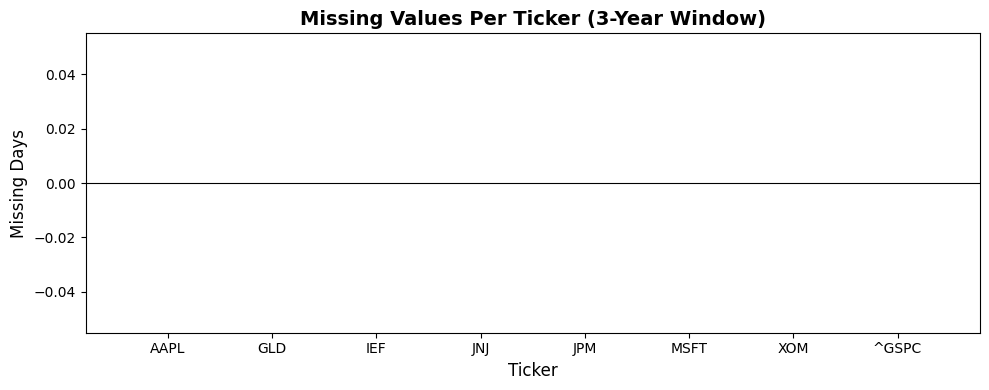

In [13]:
# ── MISSING VALUES CHECK ──────────────────────────────────────────────────────
# .isnull() returns a DataFrame of True/False values:
#   True  = value is missing (NaN = Not a Number — Python's equivalent of a blank cell)
#   False = value is present
# .sum() treats True as 1 and False as 0, so it counts the missing values per column

missing_counts = (
    prices
    .isnull()   # True where value is missing (NaN), False where it is present
    .sum()      # count the Trues per column (sum of a boolean column = count of True)
)

print('=== MISSING VALUE COUNTS PER TICKER ===')
print(missing_counts)
print()
print('Why might a stock have missing values?')
print('  -> Market holidays (the exchange was closed)')
print('  -> Trading halts (e.g. circuit breakers during a crash)')
print('  -> The asset did not exist yet (e.g. a recent IPO)')
print('  -> Data provider gap (rare but possible)')
print()

# ── VISUALISE MISSING VALUES AS A BAR CHART ───────────────────────────────────
# plt.subplots() creates a figure (the canvas) and one set of axes (the plot area).
# figsize=(width, height) in inches — controls the size of the chart.
fig, ax = plt.subplots(figsize=(10, 4))

# ax.bar() draws a bar chart on the axes we just created
ax.bar(
    missing_counts.index,    # x-axis: ticker names
    missing_counts.values,   # y-axis: number of missing days
    color='steelblue',       # fill colour of the bars
    edgecolor='white',       # thin white border between bars for clarity
)

# Add title and axis labels for professional presentation
ax.set_title(
    'Missing Values Per Ticker (3-Year Window)',
    fontsize=14,
    fontweight='bold',
)
ax.set_xlabel('Ticker',       fontsize=12)
ax.set_ylabel('Missing Days', fontsize=12)

# Add a horizontal reference line at y=0 so small bars are clearly visible
ax.axhline(0, color='black', linewidth=0.8)

# tight_layout() prevents axis labels from being clipped at the edges of the figure
plt.tight_layout()
plt.show()

In [ ]:
# ─── OPTIONAL: Save the raw price data to a CSV file ──────────────────────────
# This step is NOT required — the next session re-downloads the data fresh.
# Save only if you want to open the data in Excel or keep it for reference.

# .to_csv() writes the DataFrame to a comma-separated values file.
# In Colab, the file is saved to the virtual machine's working directory.
prices.to_csv('gis_prices_raw.csv')

print('Saved: gis_prices_raw.csv')
print()
print('You can download this file from the Colab file browser (left sidebar -> Files icon)')
print('and open it in Excel to see the same data in spreadsheet form.')

---

### Discussion Prompts

> **"Run the `describe()` output again. Which asset has the highest average price? Does a high price mean it is more expensive to own?"**
>
> *(Hint: think about what a share price represents vs. a portfolio weight. A stock trading at $500 is not necessarily more expensive than one at $50 — it depends on how many shares you hold and what that represents as a fraction of your portfolio.)*

---

> **"Look at the missing values chart. If `^GSPC` has zero missing values but `AAPL` has a few, what might explain the difference?"**
>
> *(Hint: `^GSPC` is an index computed from all S&P 500 constituents — it can always be calculated as long as some stocks are trading. Individual stocks may be halted or have data gaps that affect only that ticker.)*


---

# Section 3 — FRED: The Federal Reserve Economic Data Database

## What is FRED?

FRED (Federal Reserve Economic Data) is maintained by the **Federal Reserve Bank of St. Louis** and is the definitive public source for US macroeconomic time series. It contains over 800,000 data series — everything from monthly inflation readings to daily Treasury yields to weekly unemployment claims.

Every serious investment process involves macro data. Understanding the interest rate environment, inflation trajectory, and yield curve shape is not optional — it is the context in which every equity and fixed-income position operates.

## The 7 key series we use in this seminar

| FRED Series ID | What It Measures | Why It Matters for Investments |
|---|---|---|
| `CPIAUCSL` | Consumer Price Index (headline inflation) | Measures purchasing-power erosion; drives real return calculations |
| `DFF` | Federal Funds Effective Rate | The policy rate; signals Fed stance on growth vs. inflation |
| `GS10` | 10-year Treasury yield | Long-end rate; key input to equity discount models (DCF) |
| `GS2` | 2-year Treasury yield | Short-end rate; most sensitive to near-term Fed expectations |
| `T10Y2Y` | 10Y minus 2Y spread | Yield curve shape; inversion has preceded every US recession since 1970 |
| `DEXUSUK` | USD per GBP | FX rate for UK equity positions |
| `DEXUSEU` | USD per EUR | FX rate for European equity positions |

In this session we download the first five. `DEXUSUK` and `DEXUSEU` are covered in the portfolio analytics sessions.


## Getting a Free FRED API Key

FRED is free, but requires a brief registration to get an API key. The process takes about 2 minutes:

1. Go to **https://fred.stlouisfed.org**
2. Click **"My Account"** in the top-right corner of the page
3. Click **"Create an Account"** and register with your email address and a password
4. Once logged in, click **"My Account"** again (top-right)
5. In the account menu, select **"API Keys"**
6. Click **"Request API Key"** and enter a brief description (e.g. *"Investment analysis learning — GIS seminar"*)
7. Your API key will be shown immediately — it is a 32-character string of letters and numbers, like `a1b2c3d4e5f6a1b2c3d4e5f6a1b2c3d4`
8. **Copy the key** and paste it into the cell below, replacing `YOUR_FRED_API_KEY`

> **Security note:** Your FRED API key is low-sensitivity (it only provides read access to public data). That said, treat it like a password — do not share it publicly or post it on the internet.


In [ ]:
# ← CHANGE ME ─────────────────────────────────────────────────────────────────
# Replace the placeholder below with your own FRED API key.
# See the instructions in the cell above if you have not requested one yet.

FRED_API_KEY = 'YOUR_FRED_API_KEY'   # <- paste your 32-character key here (keep the quotes)

# Fred() creates a client object — like opening a connection to the FRED database.
# Every subsequent data request goes through this object.
# Analogy: like logging in to a Bloomberg terminal before you can pull any data.
fred = Fred(api_key=FRED_API_KEY)

print('FRED client created.')
print('If you see an authentication error in the cells below, your API key is incorrect or not yet active.')
print('Keys are usually active within a few minutes of being issued.')

In [ ]:
# ── DOWNLOAD FRED MACRO SERIES ────────────────────────────────────────────────
# fred.get_series() downloads a single FRED time series.
# Parameters:
#   series_id         = the FRED identifier string (see the table above)
#   observation_start = first date we want (same start_date as our equity data)
#   observation_end   = last date we want   (same end_date)
# Each call returns a pandas Series (a single column with a date index).

# CPI: Consumer Price Index — monthly, measures headline inflation
cpi = fred.get_series(
    'CPIAUCSL',
    observation_start = start_date,
    observation_end   = end_date,
)
cpi.name = 'CPI'   # give the Series a descriptive name (used later as a column header)
print(f'CPI downloaded: {len(cpi)} observations')

# Fed Funds Rate: overnight policy rate — daily, set by the Federal Reserve
fed_funds = fred.get_series(
    'DFF',
    observation_start = start_date,
    observation_end   = end_date,
)
fed_funds.name = 'Fed Funds Rate'
print(f'Fed Funds Rate downloaded: {len(fed_funds)} observations')

# GS10: 10-year Treasury yield — monthly, the benchmark long-term risk-free rate
gs10 = fred.get_series(
    'GS10',
    observation_start = start_date,
    observation_end   = end_date,
)
gs10.name = '10Y Treasury Yield'
print(f'10-year Treasury yield downloaded: {len(gs10)} observations')

# GS2: 2-year Treasury yield — monthly, most sensitive to near-term Fed rate expectations
gs2 = fred.get_series(
    'GS2',
    observation_start = start_date,
    observation_end   = end_date,
)
gs2.name = '2Y Treasury Yield'
print(f'2-year Treasury yield downloaded: {len(gs2)} observations')

# T10Y2Y: 10Y minus 2Y spread — daily, the yield curve shape indicator
# A negative spread = inverted yield curve = historically a recession warning signal
spread = fred.get_series(
    'T10Y2Y',
    observation_start = start_date,
    observation_end   = end_date,
)
spread.name = '10Y-2Y Spread'
print(f'10Y-2Y Spread downloaded: {len(spread)} observations')

print()

# Combine all five series into a single DataFrame using pd.concat().
# axis=1 means 'combine side by side as columns' (axis=0 would stack rows).
# join='outer' keeps all dates from all series — gaps filled with NaN.
# This is the standard way to build a multi-series macro DataFrame.
macro_df = pd.concat(
    [cpi, fed_funds, gs10, gs2, spread],
    axis=1,
    join='outer',
)

print('Macro DataFrame assembled.')
print(f'Shape: {macro_df.shape[0]} rows x {macro_df.shape[1]} columns')

In [ ]:
# ── INSPECT FRED DATA ─────────────────────────────────────────────────────────
print('=== SHAPES OF EACH MACRO SERIES ===')
print(f'  CPI (monthly):           {len(cpi):>4} observations')
print(f'  Fed Funds Rate (daily):  {len(fed_funds):>4} observations')
print(f'  10-year yield (monthly): {len(gs10):>4} observations')
print(f'  2-year yield (monthly):  {len(gs2):>4} observations')
print(f'  2Y/10Y spread (daily):   {len(spread):>4} observations')
print()
print('Key observation:')
print('  CPI is reported MONTHLY — far fewer rows than equity prices (which are DAILY).')
print('  This frequency mismatch must be resolved before any joint analysis.')
print('  Session 2 covers exactly this problem — frequency alignment and resampling.')
print()
print('=== FIRST 5 ROWS OF MACRO DATAFRAME ===')
display(macro_df.head())

In [ ]:
# ── PLOT ALL 5 FRED SERIES ────────────────────────────────────────────────────
# We create a grid of 6 subplots (3 rows, 2 columns) to show all 5 series
# side by side. The 6th panel (bottom-right) is left empty since we have 5 series.
# figsize=(14, 12) = 14 inches wide, 12 inches tall

fig, axes = plt.subplots(3, 2, figsize=(14, 12))

# plt.suptitle adds a single title above the entire grid of subplots
plt.suptitle(
    'US Macroeconomic Indicators — FRED Data (3-Year Window)',
    fontsize=16,
    fontweight='bold',
    y=1.01,   # position the title slightly above the top of the figure
)

# ── Panel 1 (row 0, col 0): CPI ───────────────────────────────────────────────
# axes[0, 0] accesses the subplot in row 0, column 0
axes[0, 0].plot(
    cpi.index,    # x-axis: dates
    cpi.values,   # y-axis: CPI level
    color='steelblue',
    linewidth=1.8,
)
axes[0, 0].set_title('Consumer Price Index (CPI)', fontweight='bold')
axes[0, 0].set_ylabel('Index Level')
axes[0, 0].grid(True, alpha=0.3)   # faint gridlines

# ── Panel 2 (row 0, col 1): Fed Funds Rate ────────────────────────────────────
axes[0, 1].plot(
    fed_funds.index,
    fed_funds.values,
    color='firebrick',
    linewidth=1.8,
)
axes[0, 1].set_title('Federal Funds Effective Rate (%)', fontweight='bold')
axes[0, 1].set_ylabel('Rate (%)')
axes[0, 1].grid(True, alpha=0.3)

# ── Panel 3 (row 1, col 0): 10-Year Treasury Yield ───────────────────────────
axes[1, 0].plot(
    gs10.index,
    gs10.values,
    color='darkorange',
    linewidth=1.8,
)
axes[1, 0].set_title('10-Year Treasury Yield (%)', fontweight='bold')
axes[1, 0].set_ylabel('Yield (%)')
axes[1, 0].grid(True, alpha=0.3)

# ── Panel 4 (row 1, col 1): 2-Year Treasury Yield ────────────────────────────
axes[1, 1].plot(
    gs2.index,
    gs2.values,
    color='seagreen',
    linewidth=1.8,
)
axes[1, 1].set_title('2-Year Treasury Yield (%)', fontweight='bold')
axes[1, 1].set_ylabel('Yield (%)')
axes[1, 1].grid(True, alpha=0.3)

# ── Panel 5 (row 2, col 0): 10Y-2Y Spread ────────────────────────────────────
axes[2, 0].plot(
    spread.index,
    spread.values,
    color='purple',
    linewidth=1.8,
)
# Add a horizontal line at zero — negative values = inverted yield curve
axes[2, 0].axhline(0, color='black', linewidth=1.0, linestyle='--')
axes[2, 0].set_title('10Y - 2Y Treasury Spread (%)', fontweight='bold')
axes[2, 0].set_ylabel('Spread (%)')
axes[2, 0].grid(True, alpha=0.3)

# ── Panel 6 (row 2, col 1): empty ────────────────────────────────────────────
# We have only 5 series but a 3x2 grid gives 6 panels.
# Turn off the empty panel so it does not show as a blank box.
axes[2, 1].axis('off')

# tight_layout() adjusts spacing between subplots to prevent overlap
plt.tight_layout()
plt.show()

print()
print('Discussion: Which periods show the sharpest change in the Fed Funds Rate?')
print('            When did the yield curve invert? What typically follows an inversion?')

In [ ]:
# ─── OPTIONAL: Save FRED macro data to a CSV file ─────────────────────────────
# As with the price data, this is NOT required for any other session.
# Save only if you want to inspect the data in Excel.

macro_df.to_csv('gis_macro_fred.csv')

print('Saved: gis_macro_fred.csv')
print('Download from: Files panel (left sidebar) -> right-click -> Download')

---

## Session 1 Debrief

### What to take away from Session 1:

- **You have now downloaded real financial data from two primary sources** — Yahoo Finance and the Federal Reserve — using fewer than 20 lines of code
- **The data arrives as a DataFrame:** rows = dates, columns = assets or indicators. Every subsequent session builds on this structure.
- **Daily equity data and monthly macro data have a frequency mismatch** — this is the central challenge Session 2 will solve. You can already see it: CPI has ~36 rows over 3 years, equity prices have ~756 rows.

---

### Discussion: "What surprised you about the data?"

> - Were there more missing values than you expected?
> - Did any price levels or macro readings look different from what you would have guessed?
> - How does this compare to pulling data manually from Bloomberg or a data spreadsheet?
> - What would it take to keep this data current in a manual process — and how does that compare to re-running this notebook?

---

### Preview of Session 2 (this afternoon):

> *"This afternoon we take the data you just downloaded and answer: 'How do I know the data is telling the truth before I draw conclusions from it?'"*
>
> We will cover: missing value strategies (forward-fill, drop, interpolate), frequency alignment (daily → monthly resampling), return calculations (simple and log returns), rolling volatility, and building the returns matrix that powers everything in Day 2.
